<a href="https://colab.research.google.com/github/ramalias/crop-monitoring-research/blob/main/model_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library and data

In [1]:
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio.plot
import os
import matplotlib.font_manager as fm
import rasterio
from rasterio.mask import mask
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from scipy.stats import uniform, randint
import seaborn as sns
import xgboost as xgb
import re
import math


!pip install contextily -q
import contextily as cx

!apt-get install -y fonts-nanum -q
!fc-cache -fv
import matplotlib.font_manager as fm

# Register the font
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


from google.colab import drive
drive.mount('/content/drive')

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 52 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,398 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/

In [2]:
RASTER_PATH = '/content/drive/MyDrive/00_shortcut/06_ARS/02_preprocess/Sentinel2/02_양파_연구/01_양파/06_final_preprocessing/2차/04_합천군/max_ndvi/S2_2024_2025_chogyemyeon_biweekly_maxndvi_final.tif'
PARCEL_PATH = '/content/drive/MyDrive/00_shortcut/06_ARS/ 01_raw_data/01_3DLab/2차전달본(0722)/2025/32652_GPKG/시군구/2025_경상남도/2025_경상남도_합천군.gpkg'

TARGET_EUPMYEON = "합천군 초계면"
ADDR_COL = "STDG_ADDR"
LABEL_COL = "CROP_NM"
TARGET_LABEL = "양파"

NODATA_VALUE = -32768
SCALE_FACTOR = 1000
SEASON_START = "2024-10-01"
year = 2025
area = 'chogye'

SPECTRAL_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
TARGET_INDICES = ["NDVI", "EVI2", "NDRE"]
ALL_TARGETS = SPECTRAL_BANDS + TARGET_INDICES

REGION_LABEL = TARGET_EUPMYEON
SEASON_LABEL = f"{year - 1}/{year}"

OUTPUT_DIR = "/content/drive/MyDrive/00_shortcut/01_양파/result"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Check raster data

In [3]:
# check
with rasterio.open(RASTER_PATH) as src:
    print("Number of bands:", src.count)
    print("Width, Height:", src.width, src.height)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Dtype:", src.dtypes)
    print("Nodata:", src.nodata)
    print("Band descriptions:", src.descriptions)
    print("Tags:", src.tags())

Number of bands: 374
Width, Height: 455 590
CRS: EPSG:32652
Bounds: BoundingBox(left=429820.0, bottom=3930590.0, right=434370.0, top=3936490.0)
Dtype: ('int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'int16', 'i

In [4]:
with rasterio.open(RASTER_PATH) as src:
    descriptions = src.descriptions

band_info = []
for i, desc in enumerate(descriptions, start=1):
    match = re.match(r"^(\d{4}-\d{2})-P([12])_([A-Z0-9]+)$", desc)
    if match:
        year_month, period, index_name = match.groups()
        band_info.append({"band_index": i, "year_month": year_month, "period": period, "index": index_name, "desc": desc})

band_df = pd.DataFrame(band_info)
target_df = band_df[band_df['index'].isin(ALL_TARGETS)].copy()   # ← changed from TARGET_INDICES

def period_to_date(year_month, period):
    day = "01" if period == "1" else "15"
    return pd.to_datetime(f"{year_month}-{day}")

target_df['date'] = target_df.apply(lambda r: period_to_date(r['year_month'], r['period']), axis=1)
target_df = target_df.sort_values(['date', 'index']).reset_index(drop=True)

print(f"Total target bands: {len(target_df)}")  # should now be 286 (13 × 22)

gdf = gpd.read_file(PARCEL_PATH)
gdf_filtered = gdf[gdf[ADDR_COL].str.contains(TARGET_EUPMYEON, na=False)].copy()

Total target bands: 286


In [5]:
target_df = band_df[band_df['index'].isin(ALL_TARGETS)].copy()
target_df['date'] = target_df.apply(lambda r: period_to_date(r['year_month'], r['period']), axis=1)
target_df = target_df.sort_values(['date', 'index']).reset_index(drop=True)

print(f"Total target bands: {len(target_df)}")
print(target_df['index'].value_counts())

Total target bands: 286
index
B11     22
B12     22
B2      22
B3      22
B4      22
B5      22
B6      22
B7      22
B8      22
B8A     22
EVI2    22
NDRE    22
NDVI    22
Name: count, dtype: int64


## Check Parcel Data

In [6]:
def map_crop_label(crop_name):
    if crop_name == "양파": return "양파"
    elif crop_name == "마늘": return "마늘"
    else: return "기타"

gdf_filtered['label'] = gdf_filtered[LABEL_COL].apply(map_crop_label)

In [7]:
gdf_filtered = gdf[gdf[ADDR_COL].str.contains(TARGET_EUPMYEON, na=False)].copy()
print(f"Parcels in {TARGET_EUPMYEON}: {len(gdf_filtered)}")

gdf_filtered['label'] = gdf_filtered[LABEL_COL].apply(map_crop_label)

print(gdf_filtered['label'].value_counts())
print()
print(gdf_filtered['label'].value_counts(normalize=True) * 100)  # percentage

Parcels in 합천군 초계면: 4039
label
기타    3206
마늘     547
양파     286
Name: count, dtype: int64

label
기타    79.376083
마늘    13.542956
양파     7.080961
Name: proportion, dtype: float64


In [8]:
gdf = gpd.read_file(PARCEL_PATH)
print(gdf.shape)
print(gdf.columns.tolist())
print(gdf.head())
print(gdf.crs)
gdf['geometry'].geom_type.value_counts()

with rasterio.open(RASTER_PATH) as src:
    raster_crs = src.crs

print("Raster CRS:", raster_crs)
print("Parcel CRS:", gdf.crs)
print("Match:", raster_crs == gdf.crs)

(101817, 32)
['ID', 'UID', 'CLSF_NM', 'CLSF_CD', 'STDG_CD', 'STDG_ADDR', 'PNU', 'LDCG_CD', 'SB_PNU', 'SB_LDCG_CD', 'AREA', 'CAD_CON_RA', 'SOURCE_NM', 'SOURCE_CD', 'FLIGHT_YMD', 'UPDT_YMD', 'UPDT_TP_NM', 'UPDT_TP_CD', 'CHG_RSN_NM', 'CHG_RSN_CD', 'FL_ARMT_YN', 'O_UID', 'O_CLSF_NM', 'FMAP_ID', 'PARCEL_ID', 'LAND_TYP', 'SURV_AREA', 'CROP_NM', 'PLT_RATE', 'MIX_CRP', 'MIX_RT', 'geometry']
                ID       UID CLSF_NM CLSF_CD     STDG_CD         STDG_ADDR  \
0  488903102100669  13956742       밭      02  4889031021  경상남도 합천군 봉산면 압곡리   
1  488903202600449  03620947       밭      02  4889032026  경상남도 합천군 묘산면 광산리   
2  488903202300452  03620617       논      01  4889032023  경상남도 합천군 묘산면 안성리   
3  488903202300034  03620162       논      01  4889032023  경상남도 합천군 묘산면 안성리   
4  488902502900315  03652598       논      01  4889025029  경상남도 합천군 합천읍 인곡리   

                   PNU LDCG_CD               SB_PNU SB_LDCG_CD  ...  \
0  4889031021102010000       답  4889031021102010000          답  ...   
1  

### CRS

In [9]:
#if only the crs different

gdf = gdf.to_crs(raster_crs)

### Parcel Visualization

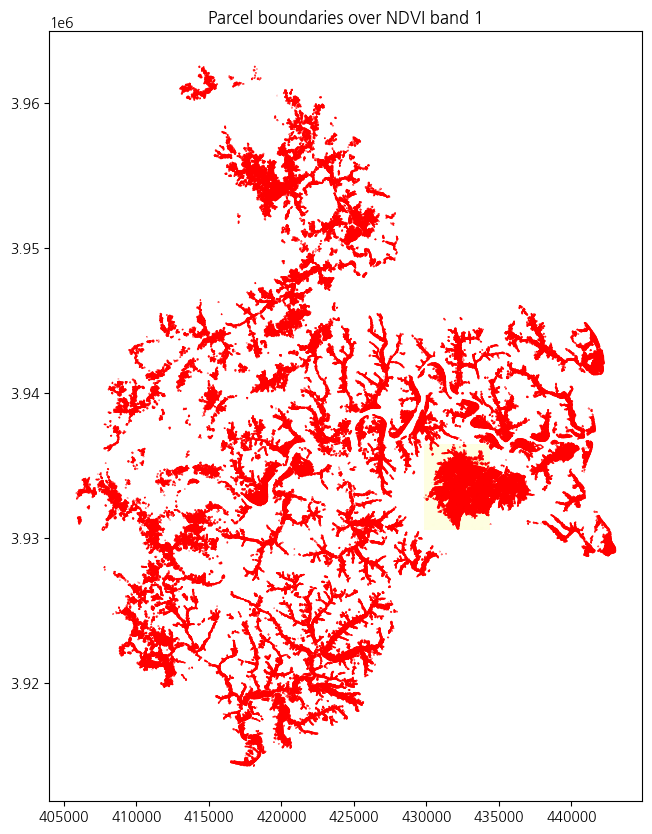

In [10]:
with rasterio.open(RASTER_PATH) as src:
    fig, ax = plt.subplots(figsize=(10, 10))
    rasterio.plot.show(src.read(1), transform=src.transform, ax=ax, cmap='YlGn')
    gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)
    plt.title("Parcel boundaries over NDVI band 1")
    plt.show()

/tmp/ipykernel_3743/3471974381.py:27: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=11, frameon=True)
/tmp/ipykernel_3743/3471974381.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=11, frameon=True)


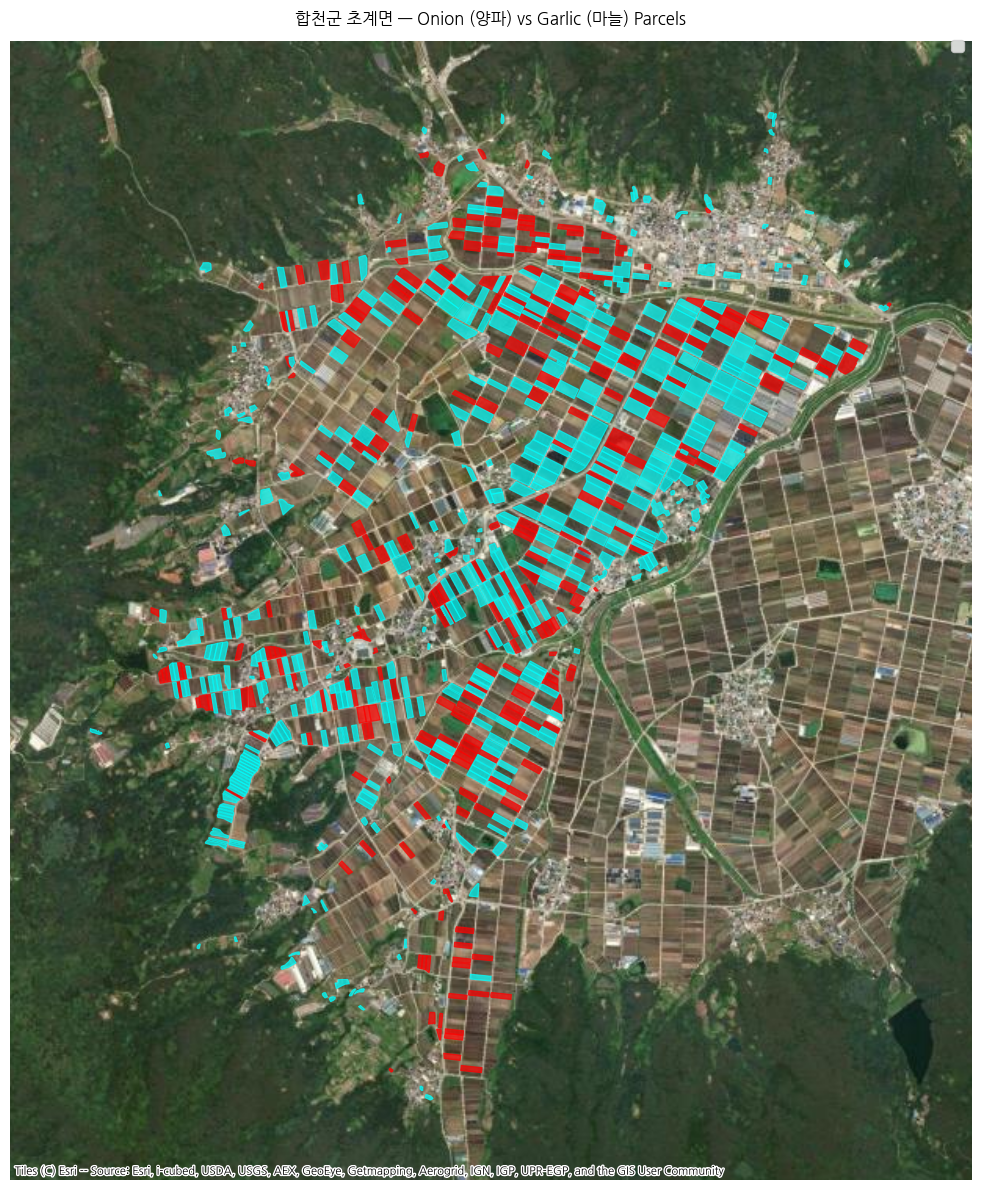

In [11]:
# ── Settings ──────────────────────────────────────────────
color_map = {'양파': 'red', '마늘': 'cyan'}  # 기타 excluded

# ── 1. Reproject parcels to Web Mercator (required for contextily basemaps) ──
gdf_web = gdf_filtered.to_crs(epsg=3857)

# ── 2. Plot ──
fig, ax = plt.subplots(figsize=(12, 12))

for label, color in color_map.items():
    subset = gdf_web[gdf_web['label'] == label]
    if len(subset) > 0:
        subset.plot(ax=ax, facecolor=color, edgecolor=color, linewidth=0.8, alpha=0.7, label=label)

# ── 3. Add satellite basemap ──
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)

# ── 4. Zoom to target parcels only ──
target_only = gdf_web[gdf_web['label'].isin(color_map.keys())]
minx, miny, maxx, maxy = target_only.total_bounds
buffer = (maxx - minx) * 0.1
ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + buffer)

ax.set_title(f"{REGION_LABEL} — Onion (양파) vs Garlic (마늘) Parcels")
ax.set_axis_off()
ax.legend(loc='upper right', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

# Xgboost

## Extract parcel

In [12]:
target_band_indices = target_df['band_index'].tolist()
feature_names = [f"{row['index']}_{row['date'].strftime('%Y%m%d')}" for _, row in target_df.iterrows()]

with rasterio.open(RASTER_PATH) as src:
    raster_crs = src.crs
if gdf_filtered.crs != raster_crs:
    gdf_filtered = gdf_filtered.to_crs(raster_crs)

records = []
with rasterio.open(RASTER_PATH) as src:
    for idx, row in tqdm(gdf_filtered.iterrows(), total=len(gdf_filtered)):
        try:
            out_image, _ = mask(src, [row.geometry], crop=True, indexes=target_band_indices)
            out_image = out_image.astype(float)
            out_image[out_image == NODATA_VALUE] = np.nan
            out_image = out_image / SCALE_FACTOR
            means = np.nanmean(out_image.reshape(out_image.shape[0], -1), axis=1)
            record = dict(zip(feature_names, means))
            record['parcel_id'] = idx
            record['label'] = row['label']
            records.append(record)
        except Exception as e:
            print(f"Skipping parcel {idx}: {e}")

feature_df = pd.DataFrame(records)
print(feature_df.shape)
print(feature_df['label'].value_counts())

  0%|          | 6/4039 [00:01<19:04,  3.52it/s]/tmp/ipykernel_3743/4274809739.py:17: RuntimeWarning: Mean of empty slice
  means = np.nanmean(out_image.reshape(out_image.shape[0], -1), axis=1)
/tmp/ipykernel_3743/4274809739.py:17: RuntimeWarning: Mean of empty slice
  means = np.nanmean(out_image.reshape(out_image.shape[0], -1), axis=1)
/tmp/ipykernel_3743/4274809739.py:17: RuntimeWarning: Mean of empty slice
  means = np.nanmean(out_image.reshape(out_image.shape[0], -1), axis=1)
  1%|          | 32/4039 [00:02<01:57, 34.00it/s]/tmp/ipykernel_3743/4274809739.py:17: RuntimeWarning: Mean of empty slice
  means = np.nanmean(out_image.reshape(out_image.shape[0], -1), axis=1)
/tmp/ipykernel_3743/4274809739.py:17: RuntimeWarning: Mean of empty slice
  means = np.nanmean(out_image.reshape(out_image.shape[0], -1), axis=1)
/tmp/ipykernel_3743/4274809739.py:17: RuntimeWarning: Mean of empty slice
  means = np.nanmean(out_image.reshape(out_image.shape[0], -1), axis=1)
  2%|▏         | 71/4039 [0

(4039, 288)
label
기타    3206
마늘     547
양파     286
Name: count, dtype: int64


In [13]:
import warnings

def safe_nan_stat(vals, func, fallback=np.nan):
    """Apply a nan-aggregation function row-wise, returning fallback for all-NaN rows."""
    all_nan_mask = np.all(np.isnan(vals), axis=1)
    result = np.full(vals.shape[0], fallback, dtype=float)
    if not np.all(all_nan_mask):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            result[~all_nan_mask] = func(vals[~all_nan_mask], axis=1)
    return result

def safe_nanargmax(vals, fallback=-1):
    """nanargmax that returns fallback instead of raising on all-NaN rows."""
    all_nan_mask = np.all(np.isnan(vals), axis=1)
    result = np.full(vals.shape[0], fallback, dtype=float)
    if not np.all(all_nan_mask):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            result[~all_nan_mask] = np.nanargmax(vals[~all_nan_mask], axis=1)
    return result

def add_seasonal_features(df, target_df, base_names):
    for name in base_names:
        cols = [f"{name}_{d.strftime('%Y%m%d')}" for d in target_df[target_df['index']==name]['date']]
        cols = [c for c in cols if c in df.columns]
        if len(cols) == 0:
            continue
        vals = df[cols].values

        df[f"{name}_max"] = safe_nan_stat(vals, np.nanmax)
        df[f"{name}_min"] = safe_nan_stat(vals, np.nanmin)
        df[f"{name}_mean"] = safe_nan_stat(vals, np.nanmean)
        df[f"{name}_std"] = safe_nan_stat(vals, np.nanstd)
        df[f"{name}_amplitude"] = df[f"{name}_max"] - df[f"{name}_min"]
        df[f"{name}_argmax"] = safe_nanargmax(vals)

        # slope: only compute where both first and last values exist
        first_val = vals[:, 0]
        last_val = vals[:, -1]
        slope = np.where(
            np.isnan(first_val) | np.isnan(last_val),
            np.nan,
            (last_val - first_val) / vals.shape[1]
        )
        df[f"{name}_slope"] = slope

    return df

feature_df = add_seasonal_features(feature_df, target_df, ALL_TARGETS)
print(feature_df.shape)

(4039, 379)


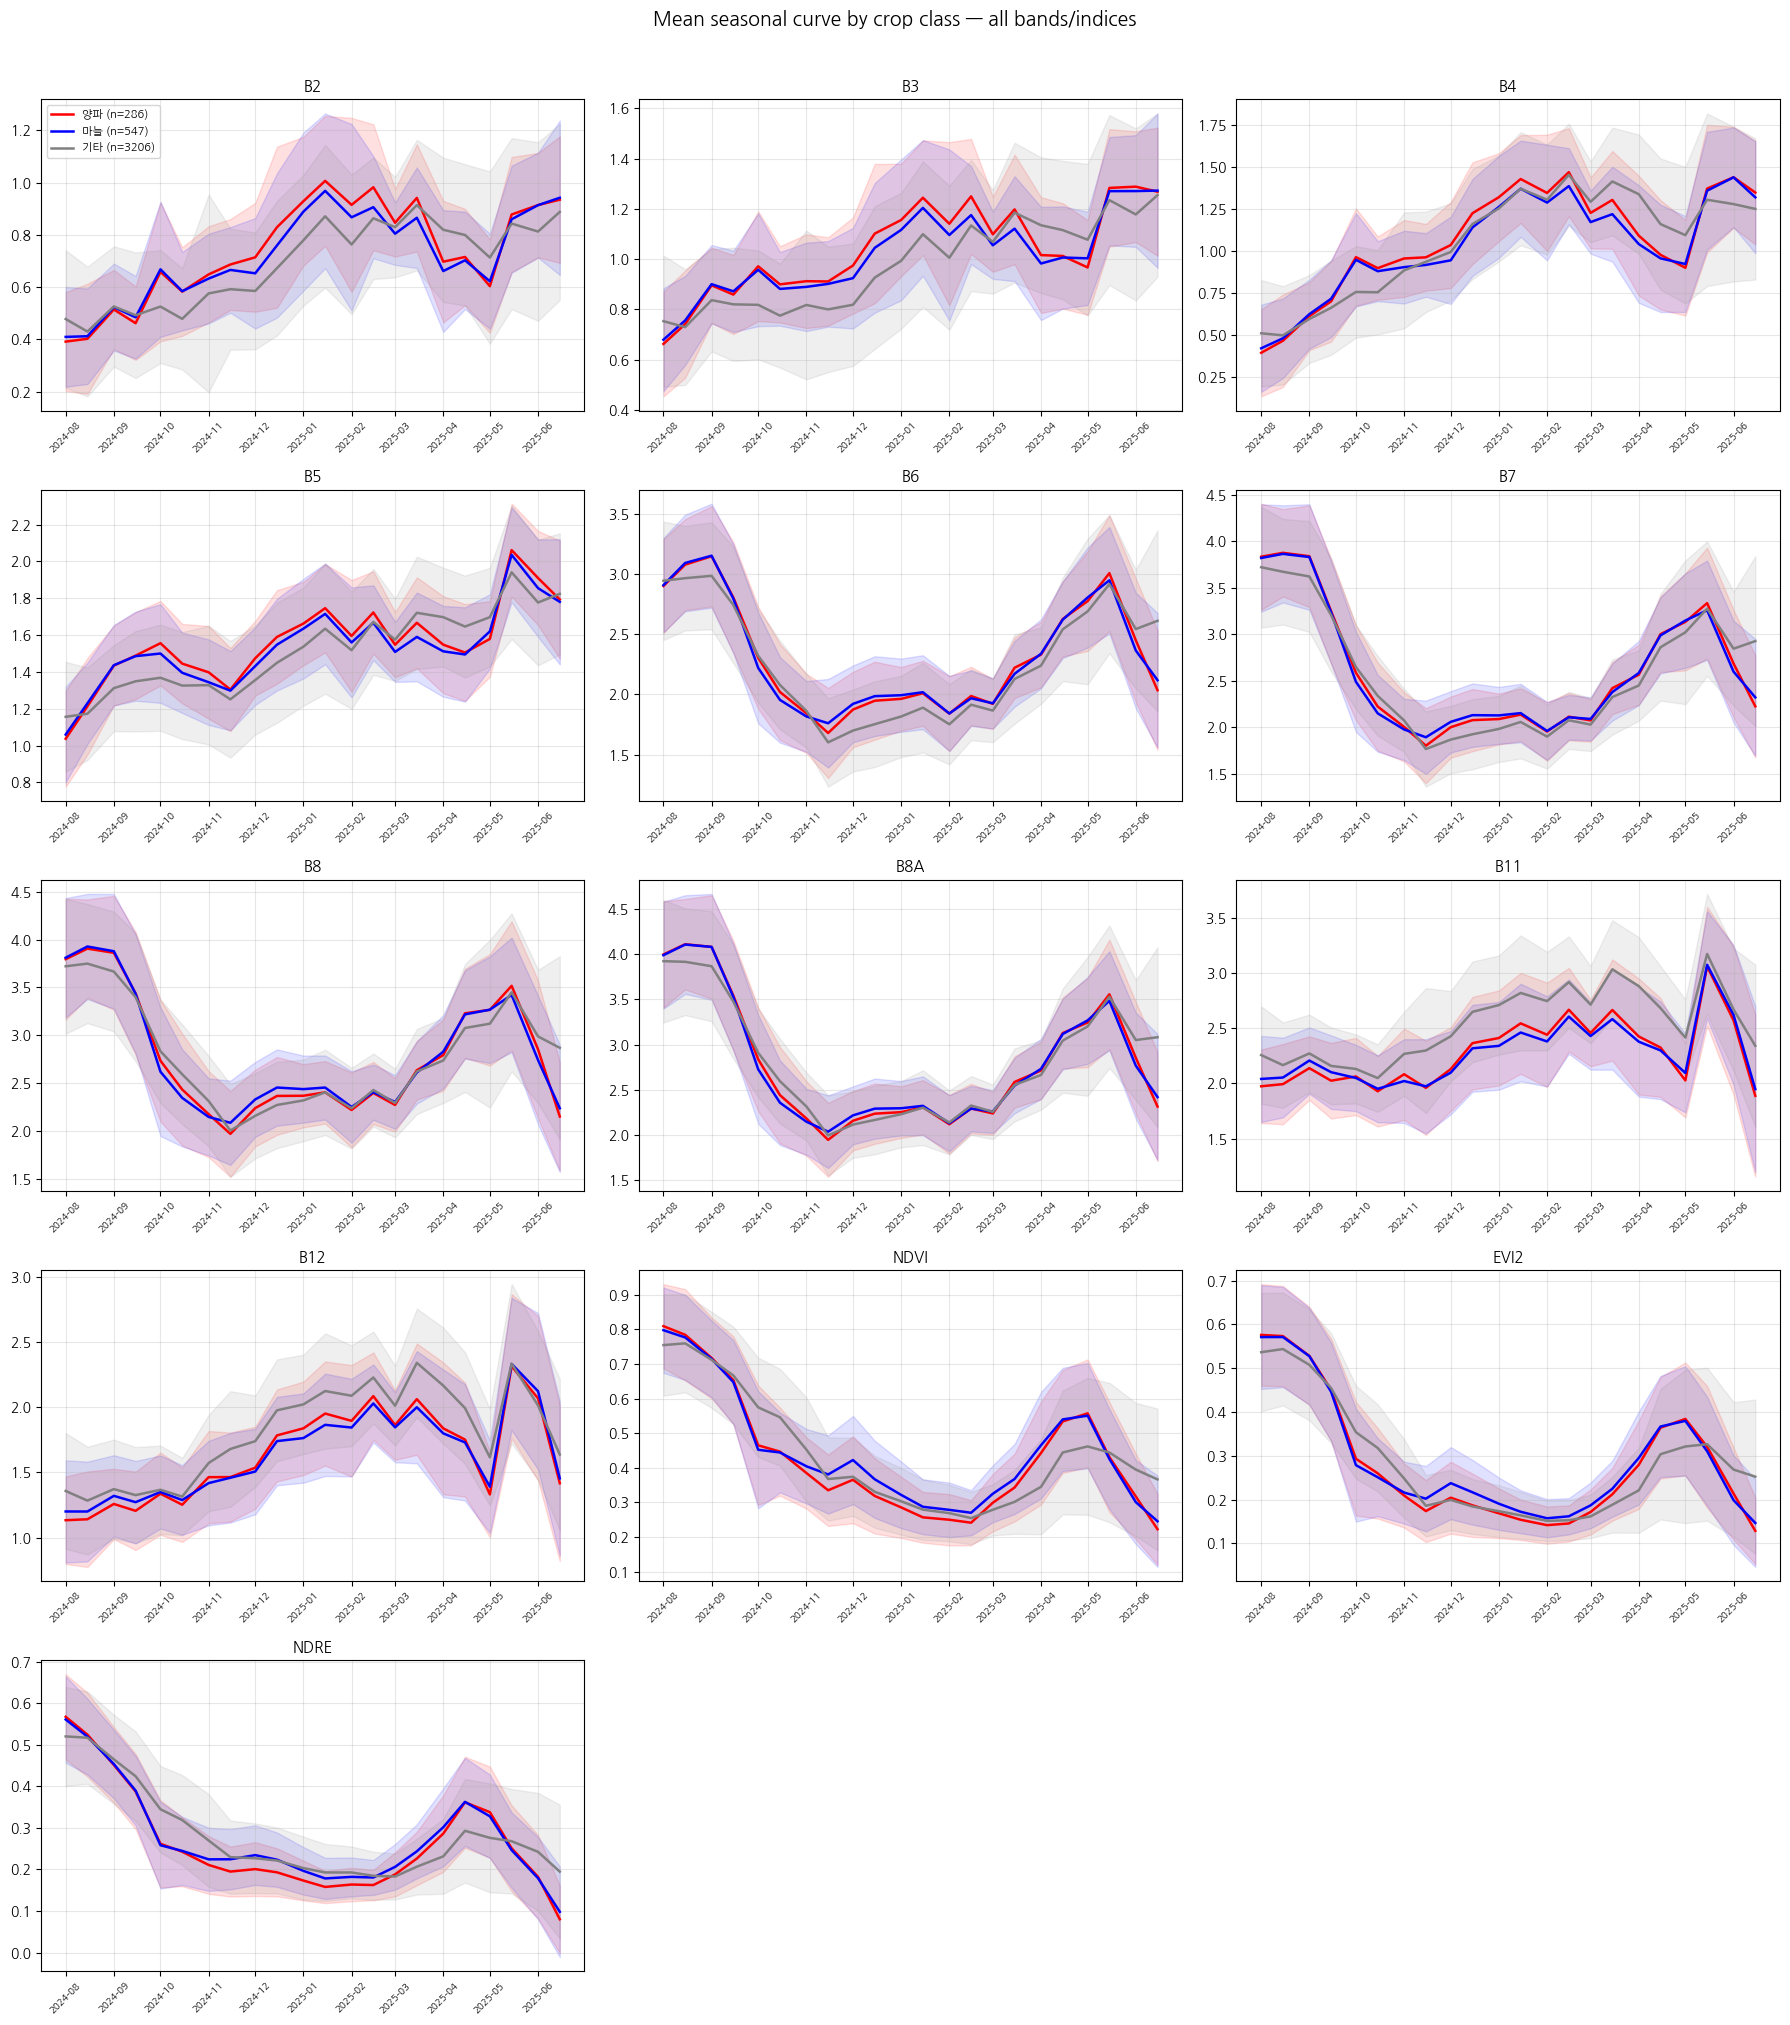

In [14]:
def plot_all_class_average_curves(feature_df, target_df, all_targets):
    n = len(all_targets)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = axes.flatten()

    colors = {'양파': 'red', '마늘': 'blue', '기타': 'gray'}

    for ax_idx, index_name in enumerate(all_targets):
        ax = axes[ax_idx]
        date_rows = target_df[target_df['index'] == index_name].sort_values('date')
        cols = [f"{index_name}_{d.strftime('%Y%m%d')}" for d in date_rows['date']]
        cols = [c for c in cols if c in feature_df.columns]
        dates = date_rows['date'].tolist()[:len(cols)]

        if len(cols) == 0:
            ax.set_visible(False)
            continue

        for label, color in colors.items():
            subset = feature_df[feature_df['label'] == label]
            mean_curve = subset[cols].mean(axis=0, skipna=True)
            std_curve = subset[cols].std(axis=0, skipna=True)

            ax.plot(dates, mean_curve, color=color, label=f'{label} (n={len(subset)})', linewidth=1.8)
            ax.fill_between(dates, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.12)

        ax.set_title(index_name, fontsize=11, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.grid(alpha=0.3)
        if ax_idx == 0:
            ax.legend(fontsize=8)

    # Hide any unused subplots
    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Mean seasonal curve by crop class — all bands/indices', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

plot_all_class_average_curves(feature_df, target_df, ALL_TARGETS)

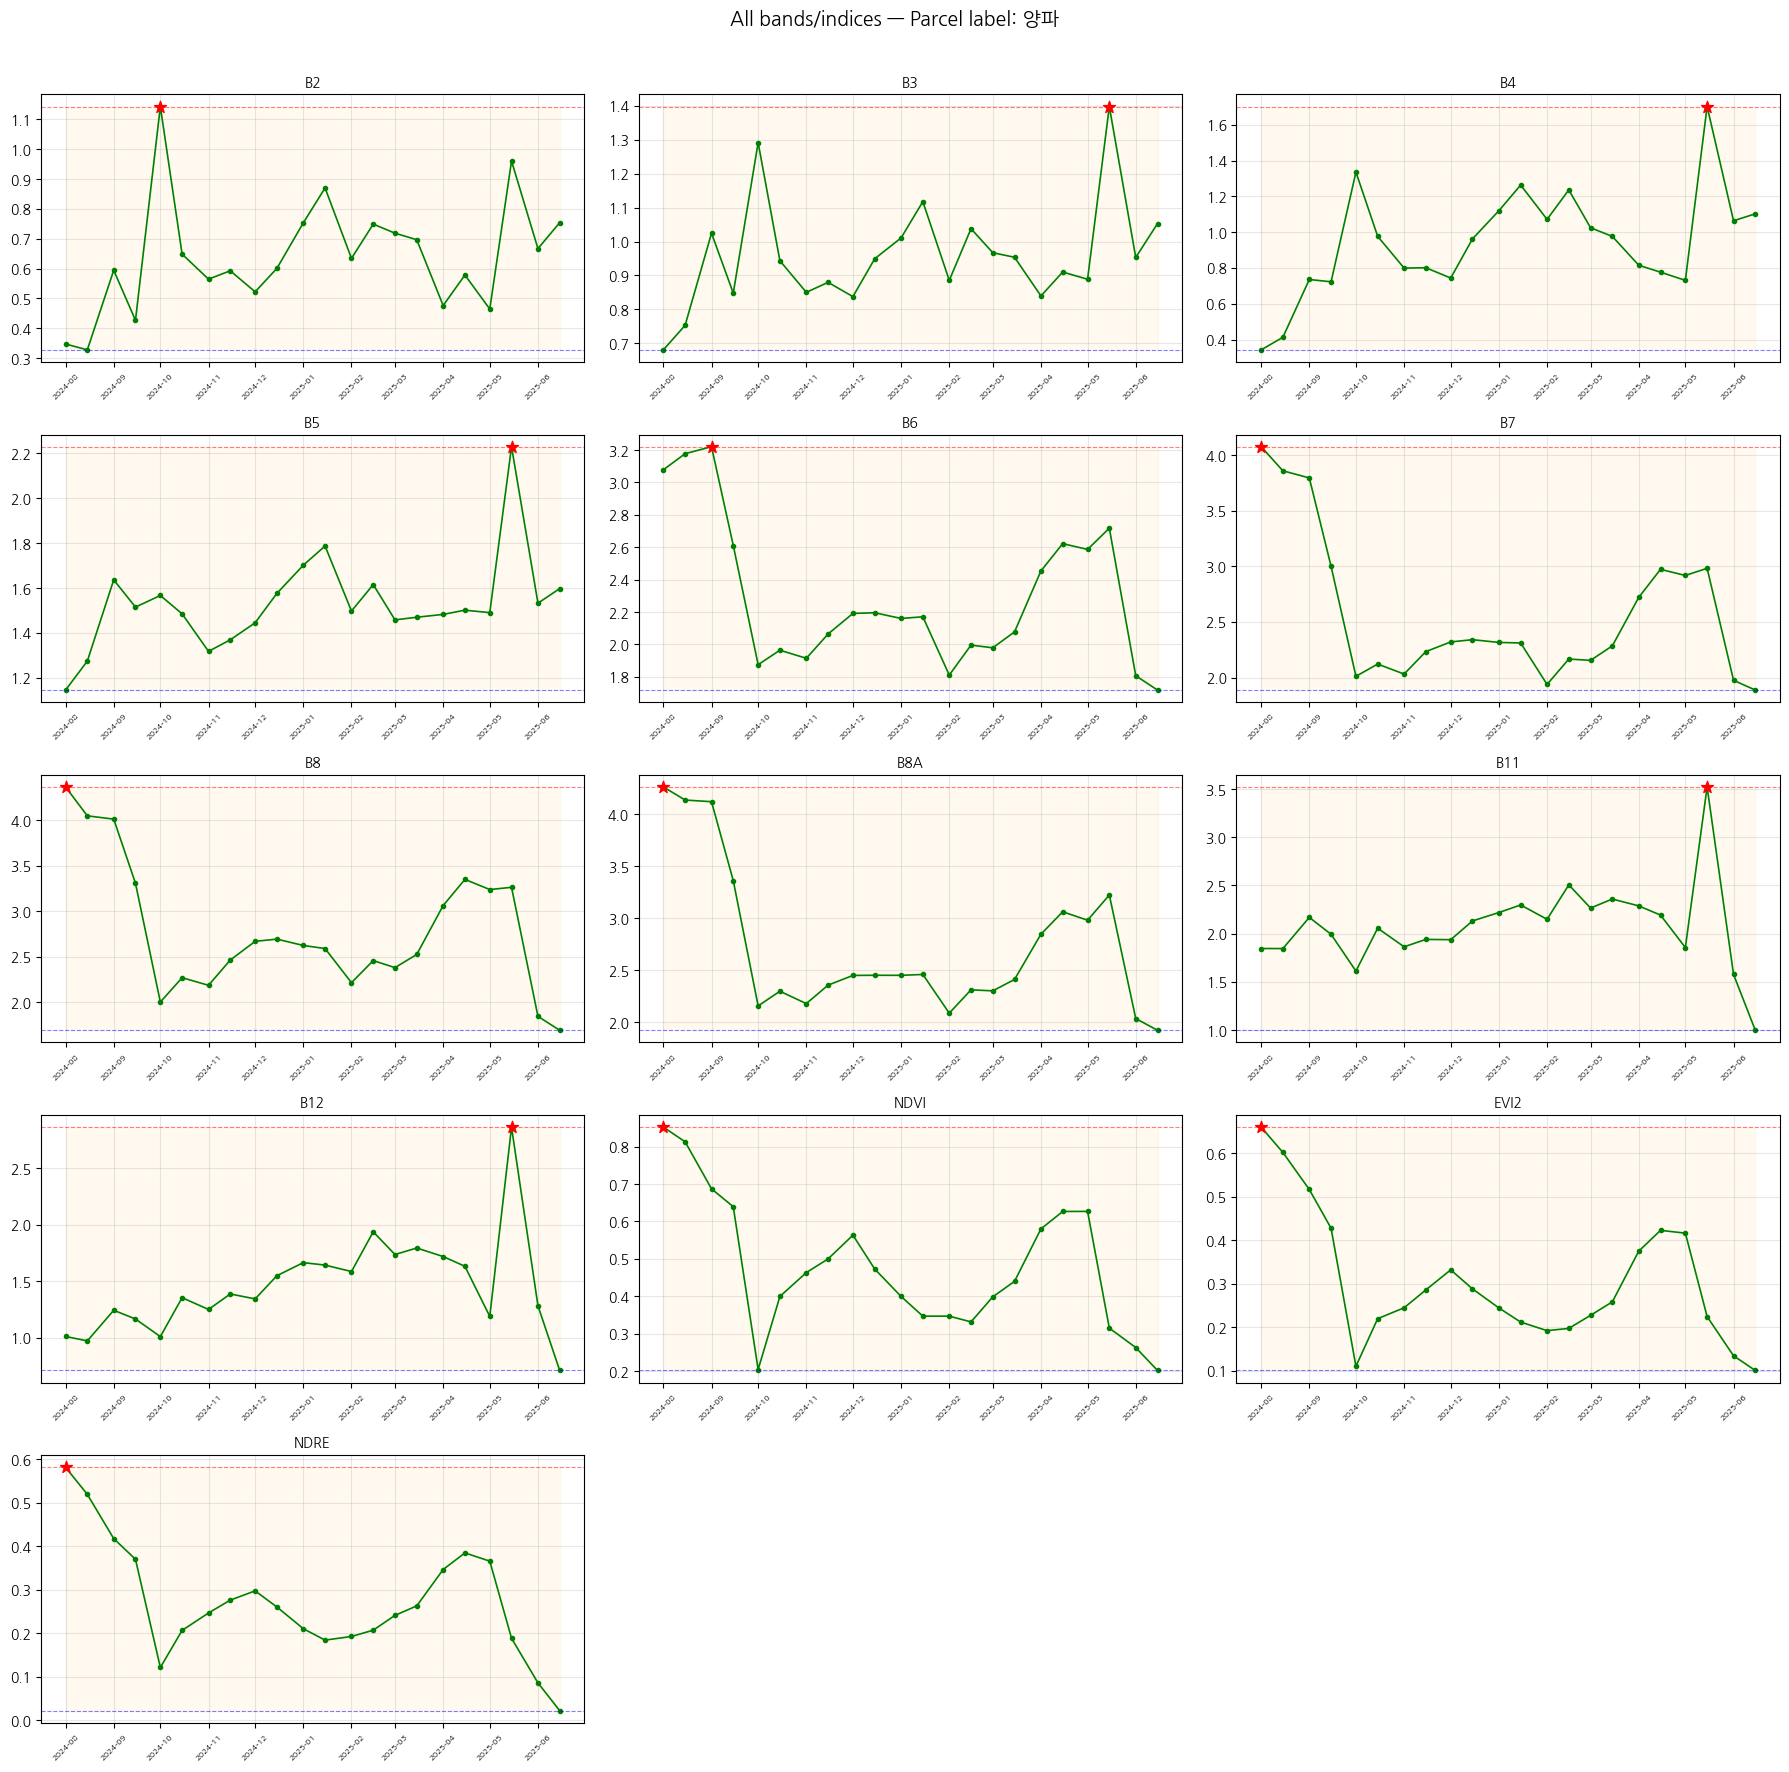

In [15]:
def visualize_all_seasonal_features(feature_df, target_df, parcel_row_idx, all_targets):
    n = len(all_targets)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3.5*nrows))
    axes = axes.flatten()

    row = feature_df.iloc[parcel_row_idx]
    label = row['label']

    for ax_idx, name in enumerate(all_targets):
        ax = axes[ax_idx]
        date_rows = target_df[target_df['index'] == name].sort_values('date')
        cols = [f"{name}_{d.strftime('%Y%m%d')}" for d in date_rows['date']]
        cols = [c for c in cols if c in feature_df.columns]
        dates = date_rows['date'].tolist()[:len(cols)]

        if len(cols) == 0:
            ax.set_visible(False)
            continue

        vals = row[cols].values.astype(float)
        ax.plot(dates, vals, marker='o', markersize=3, color='green', linewidth=1.2)

        max_val = row.get(f'{name}_max', np.nan)
        min_val = row.get(f'{name}_min', np.nan)
        argmax_idx = int(row.get(f'{name}_argmax', -1)) if not np.isnan(row.get(f'{name}_argmax', np.nan)) else -1

        ax.axhline(max_val, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
        ax.axhline(min_val, color='blue', linestyle='--', alpha=0.5, linewidth=0.8)

        if 0 <= argmax_idx < len(dates):
            ax.scatter(dates[argmax_idx], vals[argmax_idx], color='red', s=80, zorder=5, marker='*')

        ax.fill_between(dates, min_val, max_val, alpha=0.06, color='orange')
        ax.set_title(name, fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=6)
        ax.grid(alpha=0.3)

    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(f'All bands/indices — Parcel label: {label}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Example: one 양파 parcel, all bands
onion_idx = feature_df[feature_df['label'] == '양파'].index[0]
visualize_all_seasonal_features(feature_df, target_df, feature_df.index.get_loc(onion_idx), ALL_TARGETS)

In [16]:
def rank_separability(feature_df, all_targets, class_a='양파', class_b='마늘'):
    results = []
    for name in all_targets:
        mean_col = f'{name}_mean'
        max_col = f'{name}_max'
        argmax_col = f'{name}_argmax'
        if mean_col not in feature_df.columns:
            continue

        a_vals = feature_df[feature_df['label']==class_a][mean_col].dropna()
        b_vals = feature_df[feature_df['label']==class_b][mean_col].dropna()

        pooled_std = np.sqrt((a_vals.std()**2 + b_vals.std()**2) / 2)
        cohens_d = abs(a_vals.mean() - b_vals.mean()) / (pooled_std + 1e-8)

        results.append({'feature': name, 'cohens_d_mean': cohens_d})

    return pd.DataFrame(results).sort_values('cohens_d_mean', ascending=False)

separability = rank_separability(feature_df, ALL_TARGETS)
print(separability)

   feature  cohens_d_mean
12    NDRE       0.288381
10    NDVI       0.267261
2       B4       0.224341
3       B5       0.204933
1       B3       0.201161
0       B2       0.192217
11    EVI2       0.191835
6       B8       0.040338
8      B11       0.022124
5       B7       0.019808
4       B6       0.017315
9      B12       0.012210
7      B8A       0.010392


In [17]:
def bhattacharyya_distance(mean1, std1, mean2, std2):
    """Bhattacharyya distance between two univariate Gaussians."""
    term1 = 0.25 * np.log(0.25 * (std1**2/std2**2 + std2**2/std1**2 + 2))
    term2 = 0.25 * ((mean1 - mean2)**2 / (std1**2 + std2**2))
    return term1 + term2

def jm_distance(mean1, std1, mean2, std2):
    """Jeffries-Matusita distance, bounded [0, 2]. >1.9 = excellent separability."""
    b = bhattacharyya_distance(mean1, std1, mean2, std2)
    return 2 * (1 - np.exp(-b))

def compute_jm_all_pairs(feature_df, feature_cols, class_col='label'):
    classes = feature_df[class_col].unique()
    results = []
    for feat in feature_cols:
        for i, c1 in enumerate(classes):
            for c2 in classes[i+1:]:
                v1 = feature_df[feature_df[class_col]==c1][feat].dropna()
                v2 = feature_df[feature_df[class_col]==c2][feat].dropna()
                if len(v1) < 2 or len(v2) < 2:
                    continue
                jm = jm_distance(v1.mean(), v1.std(), v2.mean(), v2.std())
                results.append({'feature': feat, 'class_pair': f'{c1} vs {c2}', 'jm_distance': jm})
    return pd.DataFrame(results)

feature_cols = [c for c in feature_df.columns if c not in ['parcel_id', 'label']]
jm_df = compute_jm_all_pairs(feature_df, feature_cols)

# Best features specifically for the hardest pair: onion vs garlic
onion_garlic_jm = jm_df[jm_df['class_pair'].str.contains('양파') & jm_df['class_pair'].str.contains('마늘')]
print(onion_garlic_jm.sort_values('jm_distance', ascending=False).head(20))

            feature class_pair  jm_distance
463   NDRE_20250115   양파 vs 마늘     0.079475
385   NDRE_20241215   양파 vs 마늘     0.067261
307   NDRE_20241115   양파 vs 마늘     0.066026
346   NDRE_20241201   양파 vs 마늘     0.064870
424   NDRE_20250101   양파 vs 마늘     0.064335
541   NDRE_20250215   양파 vs 마늘     0.061675
502   NDRE_20250201   양파 vs 마늘     0.055420
514     B2_20250215   양파 vs 마늘     0.051280
853   NDRE_20250615   양파 vs 마늘     0.051262
349   NDVI_20241201   양파 vs 마늘     0.050379
1072       NDVI_min   양파 vs 마늘     0.049149
310   NDVI_20241115   양파 vs 마늘     0.048052
544   NDVI_20250215   양파 vs 마늘     0.047863
850   EVI2_20250615   양파 vs 마늘     0.047722
388   NDVI_20241215   양파 vs 마늘     0.047440
517     B3_20250215   양파 vs 마늘     0.042784
466   NDVI_20250115   양파 vs 마늘     0.042608
856   NDVI_20250615   양파 vs 마늘     0.041573
382   EVI2_20241215   양파 vs 마늘     0.041509
427   NDVI_20250101   양파 vs 마늘     0.041412


In [18]:
# jm_df already computed from earlier — just summarize all pairs
pair_summary = jm_df.groupby('class_pair')['jm_distance'].agg(['mean', 'max', 'median']).round(3)
print(pair_summary)

             mean    max  median
class_pair                      
기타 vs 마늘    0.066  0.273   0.050
양파 vs 기타    0.073  0.462   0.058
양파 vs 마늘    0.011  0.079   0.007


## main

In [19]:
feature_cols = [c for c in feature_df.columns if c not in ['parcel_id', 'label']]
feature_df[feature_cols] = feature_df[feature_cols].fillna(feature_df[feature_cols].median())

le = LabelEncoder()
feature_df['label_enc'] = le.fit_transform(feature_df['label'])
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))
print(feature_df['label'].value_counts())

X = feature_df[feature_cols]
y = feature_df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
sample_weights = compute_sample_weight('balanced', y_train)

Classes: {'기타': np.int64(0), '마늘': np.int64(1), '양파': np.int64(2)}
label
기타    3206
마늘     547
양파     286
Name: count, dtype: int64


/tmp/ipykernel_3743/458585183.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df['label_enc'] = le.fit_transform(feature_df['label'])


In [20]:
!nvidia-smi

Mon Sep 21 00:08:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [21]:
import time

start = time.time()
test_model = xgb.XGBClassifier(
    objective='multi:softprob', num_class=len(le.classes_),
    n_estimators=300, max_depth=6,
    tree_method='hist', device='cuda', random_state=42
)
test_model.fit(X_train, y_train, sample_weight=sample_weights)
print(f"GPU fit time: {time.time()-start:.2f}s")

start = time.time()
test_model_cpu = xgb.XGBClassifier(
    objective='multi:softprob', num_class=len(le.classes_),
    n_estimators=300, max_depth=6,
    tree_method='hist', device='cpu', random_state=42
)
test_model_cpu.fit(X_train, y_train, sample_weight=sample_weights)
print(f"CPU fit time: {time.time()-start:.2f}s")

GPU fit time: 1.86s
CPU fit time: 11.63s


In [22]:
param_dist = {
    'learning_rate': [0.01, 0.015, 0.025, 0.05, 0.1],
    'gamma': [0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 1],
    'max_depth': [3, 4, 5, 6, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1],
    'reg_lambda': [0.01, 0.1, 1],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'n_estimators': [100, 200, 300, 500]
}

base_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=100,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=2,
    n_jobs=1,
    random_state=42
)

random_search.fit(X_train, y_train, sample_weight=sample_weights)

print("Best parameters:", random_search.best_params_)
print("Best CV F1-macro:", random_search.best_score_)

model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [00:08:16] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.6, gamma=0.7, learning_rate=0.015, max_depth=4, min_child_weight=1, n_estimators=100, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9; total time=   0.5s
[CV] END colsample_bytree=0.6, gamma=0.7, learning_rate=0.015, max_depth=4, min_child_weight=1, n_estimators=100, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9; total time=   0.5s
[CV] END colsample_bytree=0.6, gamma=0.7, learning_rate=0.015, max_depth=4, min_child_weight=1, n_estimators=100, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9; total time=   0.6s
[CV] END colsample_bytree=0.6, gamma=0.7, learning_rate=0.015, max_depth=4, min_child_weight=1, n_estimators=100, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9; total time=   0.6s
[CV] END colsample_bytree=0.6, gamma=0.7, learning_rate=0.015, max_depth=4, min_child_weight=1, n_estimators=100, reg_alpha=0.5, reg_lambda=0.1, subsample=0.9; total time=   0.6s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.015, max_depth=6, min_child_weight=1, n_estimat

              precision    recall  f1-score   support

          기타       0.91      0.91      0.91       641
          마늘       0.54      0.47      0.50       110
          양파       0.29      0.37      0.32        57

    accuracy                           0.81       808
   macro avg       0.58      0.58      0.58       808
weighted avg       0.82      0.81      0.81       808



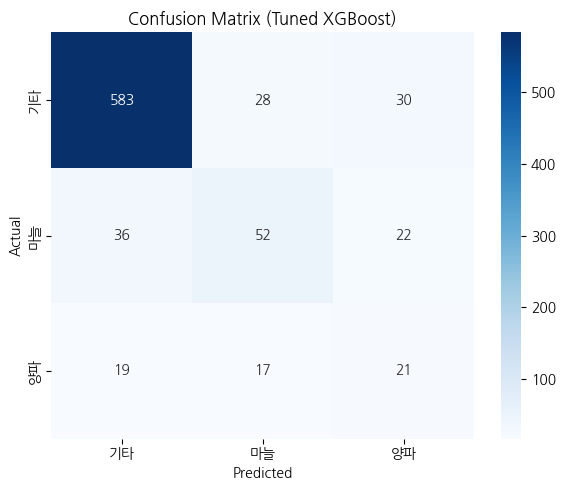

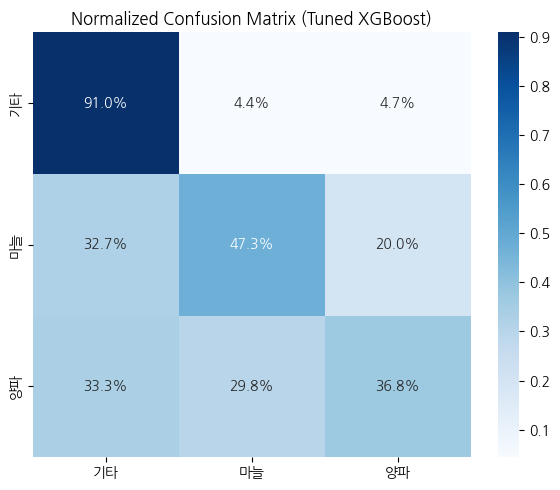

In [23]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Tuned XGBoost)')
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Normalized Confusion Matrix (Tuned XGBoost)')
plt.tight_layout()
plt.show()

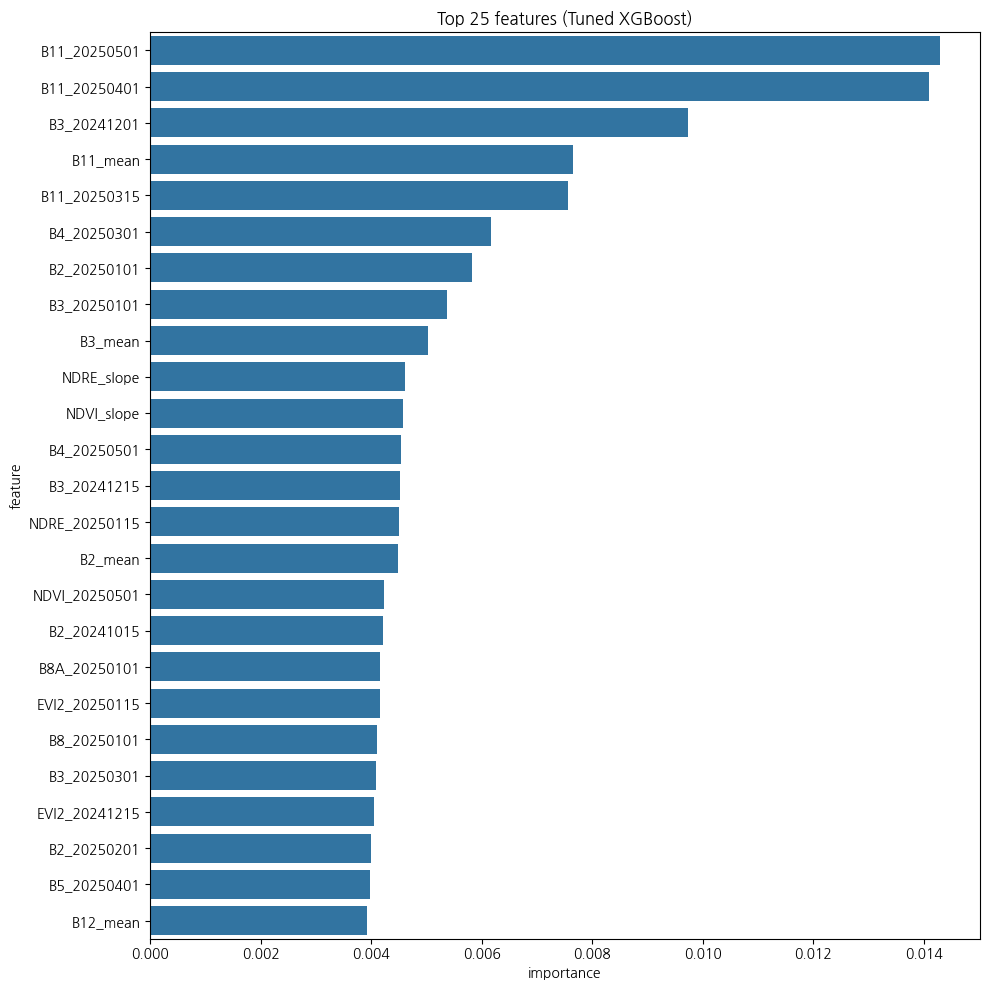

           feature  importance
234   B11_20250501    0.014299
208   B11_20250401    0.014089
107    B3_20241201    0.009723
344       B11_mean    0.007660
195   B11_20250315    0.007558
186    B4_20250301    0.006168
132    B2_20250101    0.005823
133    B3_20250101    0.005379
295        B3_mean    0.005037
376     NDRE_slope    0.004612
362     NDVI_slope    0.004569
238    B4_20250501    0.004539
120    B3_20241215    0.004525
154  NDRE_20250115    0.004500
288        B2_mean    0.004478
246  NDVI_20250501    0.004238
67     B2_20241015    0.004221
139   B8A_20250101    0.004160
153  EVI2_20250115    0.004160
138    B8_20250101    0.004106


In [24]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,10))
sns.barplot(data=importance.head(25), y='feature', x='importance')
plt.title('Top 25 features (Tuned XGBoost)')
plt.tight_layout()
plt.show()

print(importance.head(20))

In [27]:
def evaluate_input_set(X_subset, y, label_name, param_dist, n_iter=50):
    X_tr, X_te, y_tr, y_te = train_test_split(X_subset, y, test_size=0.2, stratify=y, random_state=42)
    weights = compute_sample_weight('balanced', y_tr)

    base = xgb.XGBClassifier(objective='multi:softprob', num_class=len(le.classes_),
                               eval_metric='mlogloss', random_state=42)
    search = RandomizedSearchCV(base, param_dist, n_iter=n_iter, scoring='f1_macro',
                                  cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                  n_jobs=-1, random_state=42)
    search.fit(X_tr, y_tr, sample_weight=weights)

    best = search.best_estimator_
    y_pred = best.predict(X_te)
    f1_macro = f1_score(y_te, y_pred, average='macro')
    acc = (y_pred == y_te).mean()

    print(f"\n=== {label_name} ===")
    print(f"Overall accuracy: {acc:.4f}")
    print(f"Macro-averaged F1: {f1_macro:.4f}")
    print(f"Best params: {search.best_params_}")

    return {'input_set': label_name, 'accuracy': acc, 'f1_macro': f1_macro, 'model': best}

# Input set A: raw time-series bands/indices only (exclude engineered stats)
raw_cols = [c for c in feature_cols if not any(c.endswith(suffix) for suffix in
            ['_max', '_min', '_mean', '_std', '_amplitude', '_argmax', '_slope'])]

# Input set B: raw + engineered seasonal features (everything)
all_cols = feature_cols

results = []
results.append(evaluate_input_set(X[raw_cols], y, "Series only (raw bands/indices)", param_dist, n_iter=50))
results.append(evaluate_input_set(X[all_cols], y, "Series + engineered seasonal features", param_dist, n_iter=50))

results_df = pd.DataFrame([{'input_set': r['input_set'], 'accuracy': r['accuracy'], 'f1_macro': r['f1_macro']} for r in results])
print("\n=== Summary ===")
print(results_df)


=== Series only (raw bands/indices) ===
Overall accuracy: 0.8144
Macro-averaged F1: 0.5661
Best params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.015, 'gamma': 0.3, 'colsample_bytree': 1}

=== Series + engineered seasonal features ===
Overall accuracy: 0.8082
Macro-averaged F1: 0.5626
Best params: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.015, 'gamma': 0.7, 'colsample_bytree': 0.6}

=== Summary ===
                               input_set  accuracy  f1_macro
0        Series only (raw bands/indices)  0.814356  0.566056
1  Series + engineered seasonal features  0.808168  0.562556


In [28]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')
print(f"\nF1-macro CV scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


F1-macro CV scores: [0.55767828 0.58615089 0.51827778 0.53627288 0.55241632]
Mean: 0.550 ± 0.023
